# CPMG noise spectroscopy on M1 (manipulate cavity) and the coupler

Following Bylander et al. (Nat. Phys. 2011, [arXiv:1101.4707](https://arxiv.org/abs/1101.4707)):
for each CPMG order N we acquire a coherence-decay curve vs total free-evolution time tau,
fit the envelope to get chi_N(tau), then invert the narrow-filter approximation
S(omega') = chi_N(tau) / (dwdlambda^2 * tau^2 * g_N(omega', tau) * Delta_omega).
Each N covers a range of omega' = pi*N/tau as we walk along the decay; high N reaches higher
frequencies. Goal: produce S(omega) over ~MHz–~tens of MHz for the manipulate mode first,
then for the coupler at a calibrated current set point.

Uses:
- `meas.CavityModeRamseyExperiment` with `mode='manipulate'`, `echoes=N` (CPMG timing is now
  the default).
- `meas.RamseyCouplerExperiment` with `echoes=N` (driven on `man_ch` with coupler-selective readout).
- `SweepRunner` with `sweep_param='echoes'` and `sweep_vals=[1, 2, 4, ...]` for log-spaced N.
- `fitting.noise_psd_extraction` for the per-N fits and the S(omega) inversion.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from slab import AttrDict

from experiments import MultimodeStation, CharacterizationRunner, SweepRunner
from experiments.MM_dual_rail_base import MM_dual_rail_base

import experiments as meas
from job_server import JobClient

client = JobClient()
health = client.health_check()
print(f"Server status: {health['status']}, pending: {health['pending_jobs']}")

from fitting.noise_psd_extraction import (
    filter_cpmg_data,
    fit_cpmg_decays,
    extract_psd_narrow_filter,
    plot_cpmg_decays,
    plot_envelope_diagnostic,
    plot_T2_vs_N,
    plot_psd,
)

Importing all classes from  D:\python\multimode_expts\experiments\dual_rail
Importing all classes from  D:\python\multimode_expts\experiments\qsim
Importing all classes from  D:\python\multimode_expts\experiments\qubit_cavity
Importing all classes from  D:\python\multimode_expts\experiments\single_qubit
Skipped top-level files ['characterization_runner.py', 'dataset.py', 'MM_base.py', 'MM_dual_rail_base.py', 'MM_rb_base.py', 'mock_hardware.py', 'sequential_experiment.py', 'sequential_experiment_classes.py', 'station.py', 'sweep_runner.py']
Server status: healthy, pending: 0


In [2]:
# Adjust experiment_name / config IDs to taste. If you already have a station
# created elsewhere in your session, just reuse it.

USER = 'seb'
EXPERIMENT_NAME = '260420_T2_AC_stark'


station = MultimodeStation(
    user=USER,
    experiment_name=EXPERIMENT_NAME,
    project='Stark-induced sweet spot',
    log_measurements=True,
)
USE_QUEUE = True
mm_base_calib = MM_dual_rail_base(station.hardware_cfg, station.soccfg)

[STATION] Using main hardware_config version: CFG-HW-20260513-00028
[STATION] Using main multiphoton_config version: CFG-MP-20260121-00001
[STATION] Using main man1_storage_swap version: CFG-M1-20260420-00027
[STATION] Using main floquet_storage_swap version: CFG-FL-20260223-00023
[STATION] Lab-notebook vault: H:\Shared drives\SLab\Multimode
Data, plots, logs will be stored in: D:\experiments\260420_T2_AC_stark
Hardware configs will be read from D:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260513-00028.yml
dict_keys(['Pyro.NameServer', 'Qick101'])
QICK running on ZCU216, software version 0.2.291

Firmware configuration (built Tue Oct 15 12:06:51 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	7 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 32768 samples (5.128 us)
		fs=6389.760 MHz, fabric=399.360 MHz, 32-bit DDS, range=6389.760 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 32768 

## Working point and lookups

Loads `station.data_path / coupler_lookup_tables.pkl` (produced by
[coupler_lookup_analysis.ipynb](coupler_lookup_analysis.ipynb)). Provides
polynomial lookups for f0g1 and coupler-drive frequency, plus per-current T1
(both M1 and coupler) via linear interpolation of the `characterization`
section.

Set `coupler_I_mA` below; everything downstream (M1 cfg, coupler cfg,
chi_N inversion) pulls from the resolved values.

In [21]:
# ----- Load coupler lookup table -----
# Pickle produced by coupler_lookup_analysis.ipynb. Contains polynomial
# coefficients for f0g1(I_mA) and f_coupler(I_mA), plus per-current T1
# measurements for the coupler and the manipulate cavity.

from pathlib import Path
import os
import pickle
from scipy.interpolate import interp1d

LOOKUP_PATH = Path(station.data_path) / 'coupler_lookup_tables.pkl'
if not LOOKUP_PATH.exists():
    raise FileNotFoundError(
        f'No lookup pickle at {LOOKUP_PATH}. Build it first via '
        'coupler_lookup_analysis.ipynb (or coupler_systematic_study.ipynb).'
    )
with open(LOOKUP_PATH, 'rb') as f:
    lookup = pickle.load(f)
print(f'Loaded {LOOKUP_PATH}')
print(f'  mtime: {os.path.getmtime(LOOKUP_PATH):.0f}')
print(f'  keys:  {list(lookup.keys())}')

# --- f0g1 frequency polynomial (use FINE coeffs — matches coupler_systematic_study) ---
f0g1_coeffs = np.asarray(lookup['f0g1_fine']['coeffs'], dtype=float)
f0g1_func   = np.poly1d(f0g1_coeffs)
f0g1_seed_I_mA = np.asarray(lookup['f0g1_fine']['currents_mA'], dtype=float)

# --- coupler drive frequency polynomial ---
coupler_coeffs = np.asarray(lookup['coupler']['coeffs'], dtype=float)
f_coupler_func = np.poly1d(coupler_coeffs)
coupler_seed_I_mA = np.asarray(lookup['coupler']['currents_mA'], dtype=float)

# --- per-current T1 from the characterization section ---
# `characterization` is dict keyed by current[mA] with nested T1/manipulate dicts.
_T1_rows = []
for I_key, entry in lookup.get('characterization', {}).items():
    T1_e   = entry.get('T1', {}) or {}
    man_e  = entry.get('manipulate', {}) or {}
    _T1_rows.append({
        'I_mA':            float(I_key),
        'T1_coupler_us':   float(T1_e.get('T1_us', np.nan)),
        'T1_M1_us':        float(man_e.get('T1_us',
                              entry.get('T1_manipulate', np.nan))),
    })
_T1_rows.sort(key=lambda r: r['I_mA'])
_T1_I_mA       = np.asarray([r['I_mA'] for r in _T1_rows])
_T1_coupler_us = np.asarray([r['T1_coupler_us'] for r in _T1_rows])
_T1_M1_us      = np.asarray([r['T1_M1_us'] for r in _T1_rows])

def _interp_safe(xs, ys, label):
    """Linear interp1d on the finite-valued subset. Returns None if too few points."""
    m = np.isfinite(ys)
    if m.sum() < 2:
        print(f'  [warn] {label}: <2 finite points, no interpolator (returns None)')
        return None
    return interp1d(xs[m], ys[m], kind='linear', bounds_error=False, fill_value=np.nan)

_T1_M1_interp      = _interp_safe(_T1_I_mA, _T1_M1_us,      'T1_M1')
_T1_coupler_interp = _interp_safe(_T1_I_mA, _T1_coupler_us, 'T1_coupler')

# ----- Lookup callables -----

def f0g1_lookup(I_mA):
    """f0-g1 sideband frequency [MHz] at coupler current [mA]."""
    return float(f0g1_func(I_mA))

def coupler_drive_lookup(I_mA):
    """Coupler drive (hpi) frequency [MHz] at coupler current [mA]."""
    return float(f_coupler_func(I_mA))

def T1_M1_lookup(I_mA):
    """T1 of M1 [us] at coupler current [mA]. None if no calibration."""
    if _T1_M1_interp is None: return None
    v = float(_T1_M1_interp(I_mA))
    return v if np.isfinite(v) else None

def T1_coupler_lookup(I_mA):
    """T1 of the coupler [us] at coupler current [mA]. None if no calibration."""
    if _T1_coupler_interp is None: return None
    v = float(_T1_coupler_interp(I_mA))
    return v if np.isfinite(v) else None

# ----- Working point -----
coupler_I_mA = -0.05

coupler_current_A  = coupler_I_mA * 1e-3
f0g1_freq_at_I     = f0g1_lookup(coupler_I_mA)
coupler_drive_at_I = coupler_drive_lookup(coupler_I_mA)
T1_M1              = T1_M1_lookup(coupler_I_mA)
T1_coupler         = T1_coupler_lookup(coupler_I_mA)

print(f'\nWorking point: I = {coupler_I_mA} mA  ({coupler_current_A} A)')
print(f'  f0g1            = {f0g1_freq_at_I:.4f} MHz')
print(f'  coupler drive   = {coupler_drive_at_I:.4f} MHz')
print(f'  T1 (M1)         = {T1_M1!r} us')
print(f'  T1 (coupler)    = {T1_coupler!r} us')

# --- per-current coupler hpi pulse calibration ---
# Current schema stores the hpi calibration under `rabi` (and often `rabi_verify`):
#   {pi_gain, hpi_gain, sigma, length, pulse_type, t_eff_us, ...}
# Legacy schema stored {hpi_gain, hpi_pulse_dur, sigma, pulse_type} under `T2_long`.
# We try rabi → rabi_verify → legacy T2_long in that order per current.
# `ramsey_freq_offset_MHz` lives under `T2_long` in BOTH schemas, so keep that path.
def _pick_hpi(entry):
    for key in ('rabi', 'rabi_verify'):
        d = entry.get(key)
        if isinstance(d, dict) and 'hpi_gain' in d:
            return {
                'hpi_pulse_dur': float(d.get('length',        np.nan)),
                'hpi_gain':      float(d.get('hpi_gain',      np.nan)),
                'hpi_sigma':     float(d.get('sigma',         np.nan)),
                'pulse_type':    d.get('pulse_type', None),
            }
    tl = entry.get('T2_long')
    if isinstance(tl, dict) and 'hpi_gain' in tl:
        return {
            'hpi_pulse_dur': float(tl.get('hpi_pulse_dur', np.nan)),
            'hpi_gain':      float(tl.get('hpi_gain',      np.nan)),
            'hpi_sigma':     float(tl.get('sigma',         np.nan)),
            'pulse_type':    tl.get('pulse_type', None),
        }
    return None

_cpl_rows = []
for I_key, entry in lookup.get('characterization', {}).items():
    try:
        I_mA = float(I_key)
    except (TypeError, ValueError):
        continue
    hpi = _pick_hpi(entry)
    if hpi is None:
        continue
    tl = entry.get('T2_long') if isinstance(entry.get('T2_long'), dict) else {}
    _cpl_rows.append({
        'I_mA':          I_mA,
        'ramsey_offset': float(tl.get('ramsey_freq_offset_MHz', np.nan)),
        **hpi,
    })
_cpl_rows.sort(key=lambda r: r['I_mA'])
_cpl_I_mA       = np.asarray([r['I_mA']          for r in _cpl_rows])
_cpl_dur        = np.asarray([r['hpi_pulse_dur'] for r in _cpl_rows])
_cpl_gain       = np.asarray([r['hpi_gain']      for r in _cpl_rows])
_cpl_sigma      = np.asarray([r['hpi_sigma']     for r in _cpl_rows])
_cpl_offset     = np.asarray([r['ramsey_offset'] for r in _cpl_rows])
_cpl_ptypes     = [r['pulse_type'] for r in _cpl_rows if r['pulse_type']]

_cpl_dur_interp    = _interp_safe(_cpl_I_mA, _cpl_dur,    'coupler hpi_pulse_dur')
_cpl_gain_interp   = _interp_safe(_cpl_I_mA, _cpl_gain,   'coupler hpi_gain')
_cpl_sigma_interp  = _interp_safe(_cpl_I_mA, _cpl_sigma,  'coupler hpi_sigma')
_cpl_offset_interp = _interp_safe(_cpl_I_mA, _cpl_offset, 'coupler ramsey_offset')
# Modal pulse_type (assumes consistency across the calibrated grid).
coupler_pulse_type = max(set(_cpl_ptypes), key=_cpl_ptypes.count) if _cpl_ptypes else 'const'

def coupler_hpi_length_lookup(I_mA):
    if _cpl_dur_interp is None: return None
    v = float(_cpl_dur_interp(I_mA))
    return v if np.isfinite(v) else None

def coupler_hpi_gain_lookup(I_mA):
    if _cpl_gain_interp is None: return None
    v = float(_cpl_gain_interp(I_mA))
    return int(round(v)) if np.isfinite(v) else None


def coupler_hpi_sigma_lookup(I_mA):
    if _cpl_sigma_interp is None: return None
    v = float(_cpl_sigma_interp(I_mA))
    return v if np.isfinite(v) else None

def coupler_ramsey_offset_lookup(I_mA):
    """Residual measured Ramsey detuning [MHz] at I_mA. Use as the N=0
    virtual ramsey_freq so the Ramsey fringes are resolved."""
    if _cpl_offset_interp is None: return None
    v = float(_cpl_offset_interp(I_mA))
    return v if np.isfinite(v) else None

coupler_hpi_length_at_I = coupler_hpi_length_lookup(coupler_I_mA)
coupler_hpi_gain_at_I   = coupler_hpi_gain_lookup(coupler_I_mA)
coupler_hpi_sigma_at_I  = coupler_hpi_sigma_lookup(coupler_I_mA)
coupler_ramsey_offset_at_I = coupler_ramsey_offset_lookup(coupler_I_mA)

print(f'  coupler hpi length  = {coupler_hpi_length_at_I!r} us')
print(f'  coupler hpi gain    = {coupler_hpi_gain_at_I!r} DAC')
print(f'  coupler hpi sigma   = {coupler_hpi_sigma_at_I!r} us')
print(f'  coupler pulse_type  = {coupler_pulse_type!r}')
print(f'  coupler ramsey off  = {coupler_ramsey_offset_at_I!r} MHz')


Loaded D:\experiments\260420_T2_AC_stark\data\coupler_lookup_tables.pkl
  mtime: 1778797980
  keys:  ['notebook', 'user', 'experiment_name', 'I_start_mA', 'I_stop_mA', 'f0g1_coarse', 'f0g1_fine', 'coupler', 'characterization']

Working point: I = -0.05 mA  (-5e-05 A)
  f0g1            = 1974.2229 MHz
  coupler drive   = 4685.8066 MHz
  T1 (M1)         = 161.62959200447054 us
  T1 (coupler)    = 83.76638466081717 us
  coupler hpi length  = 5.0 us
  coupler hpi gain    = 10048 DAC
  coupler hpi sigma   = 0.035 us
  coupler pulse_type  = 'gauss'
  coupler ramsey off  = 11.729030632158475 MHz


In [8]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
singleshot_defaults = AttrDict(dict(    
    reps=5000,
    relax_delay=500,
    check_f=False,
    active_reset=False,
    man_reset=False,
    storage_reset=False,
    qubit=0,
    pulse_manipulate=False,
    cavity_freq=4984.373226159381,
    cavity_gain=400,
    cavity_length=2,
    prepulse=False,
    pre_sweep_pulse=None,
    gate_based=True,
    qubits=[0],
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def singleshot_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    # add the active reset dict to the expt config so that it can be used in the postprocessor
    
    return expt_cfg



def singleshot_postproc(station, expt):
    expt.analyze(plot=False, station=station, subdir=station.autocalib_path)
    fids = expt.data['fids']
    confusion_matrix = expt.data['confusion_matrix']
    thresholds_new = expt.data['thresholds']
    angle = expt.data['angle']
    print(fids)

    hardware_cfg = station.hardware_cfg
    hardware_cfg.device.readout.phase = [hardware_cfg.device.readout.phase[0] + angle]
    hardware_cfg.device.readout.threshold = thresholds_new
    hardware_cfg.device.readout.threshold_list = [thresholds_new]
    hardware_cfg.device.readout.Ie = [np.median(expt.data['Ie_rot'])]
    hardware_cfg.device.readout.Ig = [np.median(expt.data['Ig_rot'])]
    if expt.cfg.expt.active_reset:
        hardware_cfg.device.readout.confusion_matrix_with_active_reset = confusion_matrix
    else:
        hardware_cfg.device.readout.confusion_matrix_without_reset = confusion_matrix
    print('Updated readout!')


Job submitted: JOB-20260514-00263 (queue position: 1)

[0.1s] Job JOB-20260514-00263: pending

[2.2s] Job JOB-20260514-00263: running
[WORKER] Loading HistogramExperiment from experiments.single_qubit.single_shot
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260514-00263_HistogramExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to -0.05mA according to expt.cfg...
[WORKER] Done setting coupler current
 66%|████████████████████████▏            | 3276/5000 [00:06<00:03, 498.89it/s]
[27.3s] Job JOB-20260514-00263: completed
100%|█████████████████████████████████████| 5000/5000 [00:10<00:00, 499.45it/s]
Unrotated:
Ig -85.36621621621622 +/- 27.34541869430861 	 Qg -65.8918918918919 +/- 26.401794174141905 	 Amp g 107.8384545891054
Ie 14.693243243243243 +/- 29.518831834196234 	 Qe -68.79594594594595 +/- 25.913570732295767 	 Amp e 70.34752003875211
Rotated:
Ig -83.35030750943544 +/- 27.357717734392224 	 Qg -68.33228034141962 +/- 26.3890496143

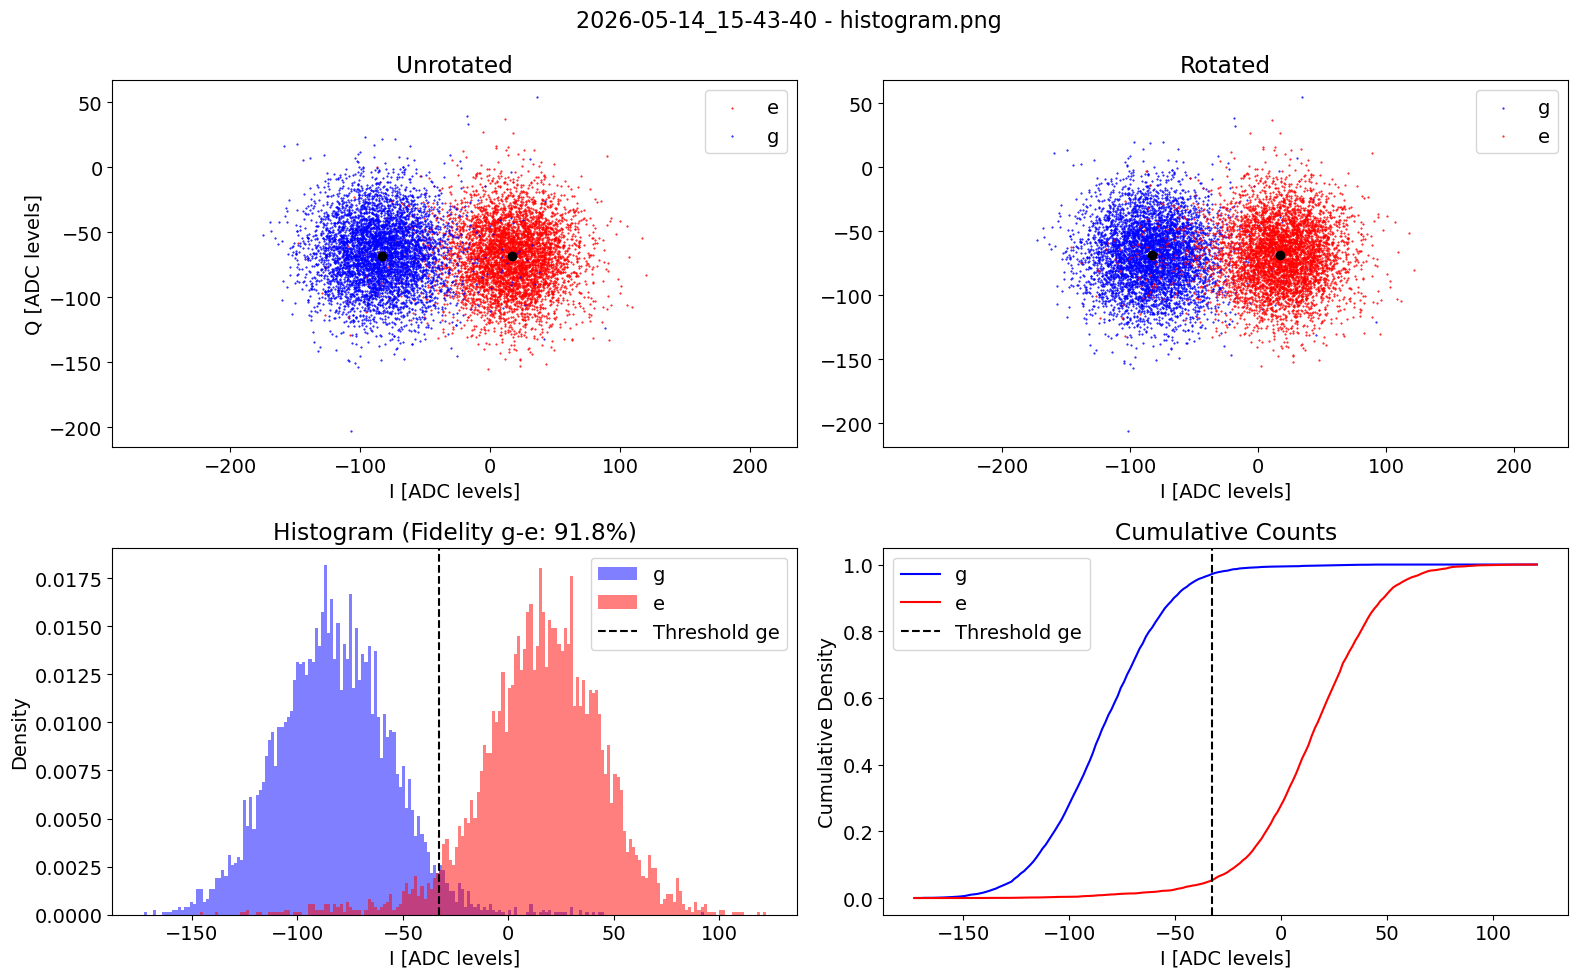

[log_measurement] Appended section to H:\Shared drives\SLab\Multimode\Lab\seb\Stark-induced sweet spot\2026\05\2026-05-14.md


In [17]:
single_shot_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.HistogramExperiment,
    default_expt_cfg = singleshot_defaults,
    postprocessor = singleshot_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

single_shot = single_shot_runner.execute(
        go_kwargs=dict(analyze=False, display=False),
        check_f=False,
        relax_delay=2000,
        pre_sweep_pulse=None,
        prepulse=False,
        gate_based=False,
        reps=5000,
        coupler_current=float(coupler_I_mA * 1e-3), 
    )

## 1) M1 (manipulate) CPMG

Each N runs as its own sequential job. Pick N values and a tau sweep that resolves the decay
well at the lowest N (longest T2) without exhausting hardware time. The same `start/step/expts`
are reused for every N — that's fine since CPMG sequences with larger N decay slower, so the
tau window remains within T2(N).

In [11]:
manipulate_cfg = AttrDict(dict(
    start=0.01,
    step=0.02*50,
    expts=200,
    ramsey_freq=0.025,
    reps=250,
    rounds=1,
    qubits=[0],
    active_reset=False,
    mode='manipulate',
    man_mode_idx=1,
    man_mode_no=1,
    echoes=0,
    parity_meas=False,
    # Setpoint pulled from the working-point cell above:
    coupler_current=coupler_current_A,
    f0g1_freq=f0g1_freq_at_I,
))

manipulate_runner = SweepRunner(
    station=station,
    ExptClass=meas.CavityModeRamseyExperiment,
    default_expt_cfg=manipulate_cfg,
    sweep_param='echoes',
    job_client=client,
    use_queue=client is not None,
)

Sweep: echoes from 0 to 4 (4 pts)
  File: D:\experiments\260420_T2_AC_stark\data\00023_CavityModeRamseyExperiment_sweep.h5
  [1/4] echoes=0.0000 Job submitted: JOB-20260514-00254 (queue position: 1)
[WORKER] Loading CavityModeRamseyExperiment from experiments.single_qubit.t2_cavity_mode
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260514-00254_CavityModeRamseyExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to -0.05mA according to expt.cfg...
[WORKER] Done setting coupler current
Config expt: {'start': 0.01, 'step': 2, 'expts': 200, 'ramsey_freq': 3.5649665689789005, 'reps': 200, 'rounds': 1, 'qubits': [0], 'active_reset': False, 'mode': 'manipulate', 'man_mode_idx': 1, 'man_mode_no': 1, 'echoes': 0, 'parity_meas': False, 'coupler_current': -5e-05, 'f0g1_freq': 1974.2228731878513, 'sweep': {'param': 'echoes', 'start': 0.0, 'stop': 4.0, 'npts': 4}}
f0g1_freq_override: 1974.2228731878513
Ramsey pulse: [[1974.2228731878513]
 [8000]
 [

D:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\numpy\fft\helper.py:218: RuntimeWarning: divide by zero encountered in divide
  val = 1.0/(n*d)


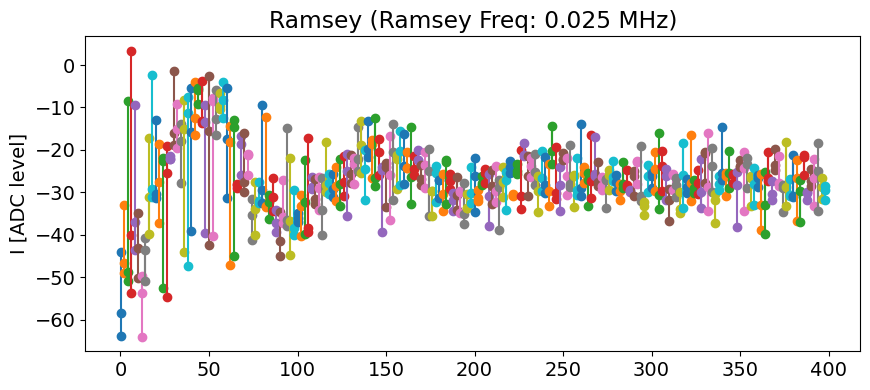

In [12]:
# Run the sweep, including N=0 (plain Ramsey) and CPMG N>=1 in a single call.
# Use per_point_cfg to flip ramsey_freq between the two regimes:
#   N=0  : large virtual detuning, well-resolved Ramsey fringes
#   N>=1 : small detuning so the CPMG envelope dominates the fit
# N_values_man = [0, 1, 2, 4]
N_values_man = [0, 1, 2, 4]

def manipulate_ramsey_freq_for(N, _cfg):
    return {'ramsey_freq': 3.5549665689789007+0.01 if int(N) == 0 else 0.01}

mother_man = manipulate_runner.execute(
    sweep_start=min(N_values_man),
    sweep_stop=max(N_values_man),
    sweep_npts=len(N_values_man),
    sweep_vals=N_values_man,
    per_point_cfg=manipulate_ramsey_freq_for,
    reps=200,
    expts=200,
    step=2,
)

Manipulate T2(N) [us]:
  N=  0  T2=  69.042 us  envelope=exp
  N=  1  T2= 100.008 us  envelope=exp
  N=  2  T2= 134.966 us  envelope=exp
  N=  4  T2= 383.804 us  envelope=exp


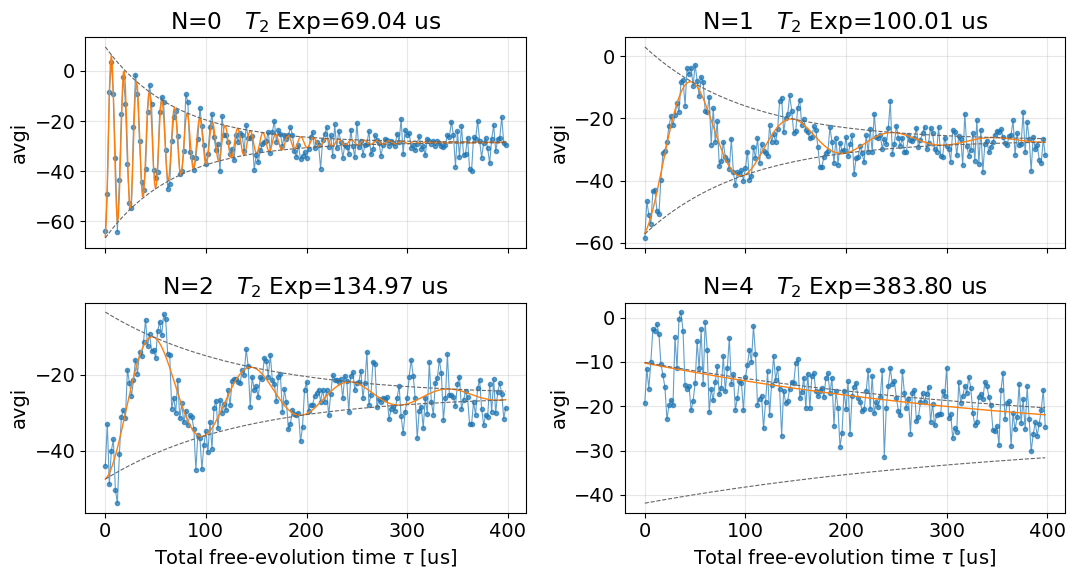

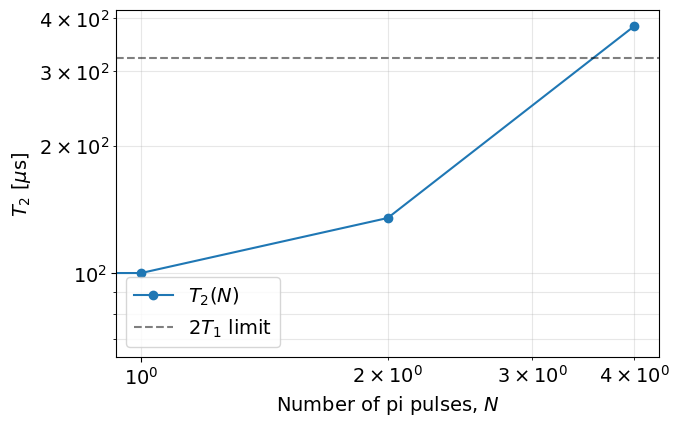

In [13]:
# Fit each CPMG-N decay and extract per-N T2.
fits_man = fit_cpmg_decays(
    mother_man.data,
    channel='avgi',
    sweep_param_key='echoes_sweep',
    use_x0=False,
    gauss_ssr_margin=0.05,
)
print('Manipulate T2(N) [us]:')
for N, T2, env in zip(fits_man['N_values'], fits_man['T2'], fits_man['envelope']):
    print(f'  N={int(N):3d}  T2={T2:8.3f} us  envelope={env}')

# Per-N Ramsey-vs-time view with fit overlay (one subplot per N).
fig = plot_cpmg_decays(mother_man.data, fits_man, channel='avgi',
                       sweep_param_key='echoes_sweep')
plt.show()

# T1_M1 was resolved from T1_M1_lookup(coupler_I_mA) in the working-point cell.
fig = plot_T2_vs_N(fits_man, T1=T1_M1)
plt.show()

tau_pi_M1 = 1133.4 ns  (= 2 * (hpi_ge 0 + pi_ef 0 + pi_fg 567) ns)
[simple] 2 points across 2 N values
[data-driven] 367 points across 3 N values


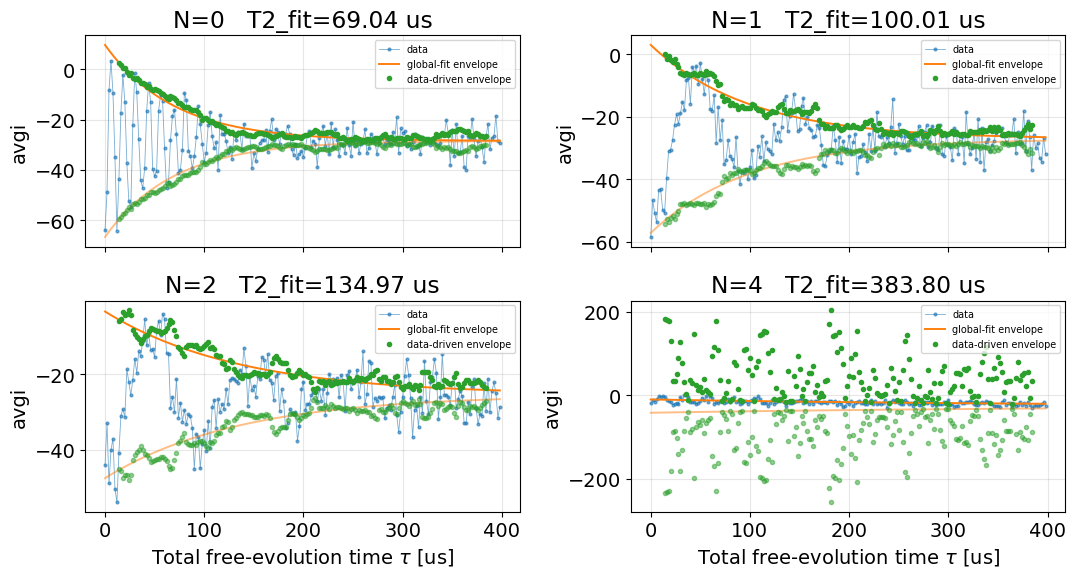

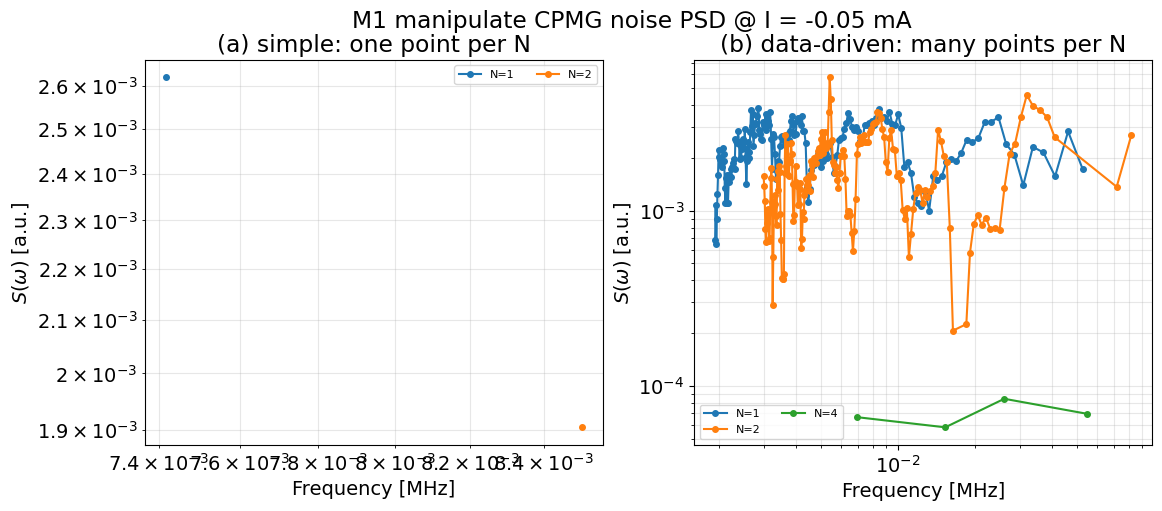

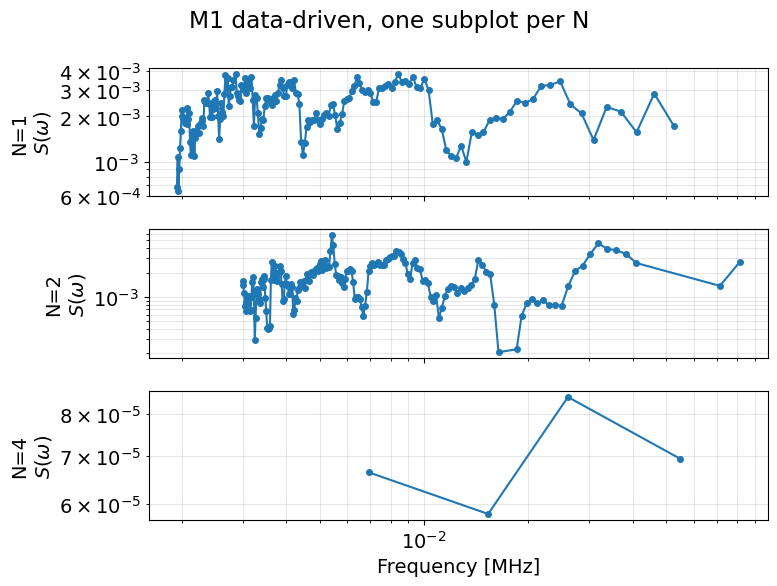

In [14]:
# ----- pi-pulse width (Bylander filter correction) -----
# The CPMG filter g_N includes a cos(omega * tau_pi / 2) factor per pi pulse
# (Bylander Eq. 22). For an M1 echo "pulse" the actual sequence is
#   prep[::-1] + prep
# with prep = [g0-e0 hpi, e0-f0 pi, f0-g1 pi]  (see prep_man_fock_state
# in MM_base.py:1850-1856 for state='+'). Total tau_pi = sum of those 6
# sub-pulse durations, pulled from the hardware-config multiphoton table.
_mp = station.hardware_cfg.device.multiphoton
_t_hpi_ge = float(_mp['hpi']['gn-en']['length'][0])
_t_pi_ef  = float(_mp['pi']['en-fn']['length'][0])
_t_pi_fg  = float(_mp['pi']['fn-gn+1']['length'][0])
tau_pi_M1 = 2.0 * (_t_hpi_ge + _t_pi_ef + _t_pi_fg)  # [us]
print(f'tau_pi_M1 = {tau_pi_M1*1e3:.1f} ns  '
      f'(= 2 * (hpi_ge {_t_hpi_ge*1e3:.0f} + pi_ef {_t_pi_ef*1e3:.0f} '
      f'+ pi_fg {_t_pi_fg*1e3:.0f}) ns)')

# ----- (a) Simple method: one S(omega) point per N (Bylander Fig. 2g) -----
# Honest accounting of what the global envelope fit constrains: each N gives
# one point at the characteristic frequency omega_N = pi*N/T2(N).
psd_man_simple = extract_psd_narrow_filter(
    fits_man, mode='simple', T1=T1_M1, dwdlambda=1.0, tau_pi=tau_pi_M1,
)
print(f'[simple] {len(psd_man_simple["freq_MHz"])} points across '
      f'{len(np.unique(psd_man_simple["N"]))} N values')

# ----- (b) Data-driven method: chi_N(tau) from raw oscillating data -----
# Windowed amplitude fit at each tau (Bylander Eq. 24 spirit). Each tau gives
# a genuinely independent S(omega') point — the "dot cloud per N" from Fig. 4.
psd_man_data = extract_psd_narrow_filter(
    fits_man, mode='data_driven',
    mother_data=mother_man.data, channel='avgi',
    sweep_param_key='echoes_sweep',
    T1=T1_M1, dwdlambda=1.0, tau_pi=tau_pi_M1,
    tau_skip_initial=2, env_window=15, env_floor_frac=0.02,
    env_anchor='global_fit',
)
print(f'[data-driven] {len(psd_man_data["freq_MHz"])} points across '
      f'{len(np.unique(psd_man_data["N"]))} N values')

# ----- Diagnostic: raw data + global-fit envelope + data-driven envelope -----
# Eyeball whether the data-driven envelope adds new info (frequency-dependent
# S) or just tracks the global fit (essentially white dephasing in the band).
fig = plot_envelope_diagnostic(mother_man.data, fits_man, channel='avgi',
                               sweep_param_key='echoes_sweep', window=15)
plt.show()

# ----- Final S(omega) plot -----
# Compare the two methods side-by-side:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_psd(psd_man_simple, ax=axes[0], style='overlay')
axes[0].set_title('(a) simple: one point per N')
plot_psd(psd_man_data, ax=axes[1], style='overlay')
axes[1].set_title('(b) data-driven: many points per N')
fig.suptitle(f'M1 manipulate CPMG noise PSD @ I = {coupler_I_mA} mA')
plt.show()

# Faceted view of the data-driven result (one subplot per N):
fig = plot_psd(psd_man_data, style='faceted')
fig.suptitle('M1 data-driven, one subplot per N')
plt.show()

## 2) Coupler CPMG (at a calibrated set point)

Same machinery, with two extras:
- `coupler_current` (Amps) tells the worker to ramp the Yoko before each job.
- `f0g1_freq` (MHz) overrides the readout-swap calibration for that set point.

If `coupler.pulses.pi` is not yet calibrated for the coupler, the experiment
falls back to scaling the `hpi` entry by gain * 2 (with a warning printed by
the program at startup). Better to calibrate it explicitly and add it to the
hardware config via `station.snapshot_hardware_config(update_main=True)`.

In [40]:
coupler_cfg = AttrDict({
    'qubits': [0],
    'man_mode_no': 1,
    'echoes': 0,                  # overwritten by SweepRunner per point
    # Pulse params from the per-current calibration (T2_long subentries):
    'pulse_type': coupler_pulse_type,
    'freq':       coupler_drive_at_I,
    'gain':       coupler_hpi_gain_at_I,
    'length':     coupler_hpi_length_at_I,  # used when pulse_type='const'
    'sigma':      coupler_hpi_sigma_at_I,   # used when pulse_type='gauss'
    'start': 0.0,
    'step': 0.05,
    'expts': 100,
    'ramsey_freq': 2.0,            # default; per_point_cfg below overrides
    'reps': 500,
    'rounds': 1,
    'coupler_current': coupler_current_A,
    'f0g1_freq':       f0g1_freq_at_I,
    # Optional pi-pulse overrides (only used when echoes>=1); falls back to
    # coupler.pulses.pi or hpi * 2 (with a warning) if not provided.
    # 'pi_freq':   <MHz>,
    # 'pi_length': <us>,
    # 'pi_sigma':  <us>,
    # 'pi_gain':   <DAC>,
})

coupler_runner = SweepRunner(
    station=station,
    ExptClass=meas.RamseyCouplerExperiment,
    default_expt_cfg=coupler_cfg,
    sweep_param='echoes',
    job_client=client,
    use_queue=client is not None,
)

Sweep: echoes from 1 to 8 (4 pts)
  File: D:\experiments\260420_T2_AC_stark\data\00004_RamseyCouplerExperiment_sweep.h5
  [1/4] echoes=1.0000 Job submitted: JOB-20260514-00275 (queue position: 1)
[WORKER] Loading RamseyCouplerExperiment from experiments.single_qubit.ramsey_coupler
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260514-00275_RamseyCouplerExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to -0.05mA according to expt.cfg...
[WORKER] Done setting coupler current
man_ch=3 freq_reg=12 phase_reg=13 gain_reg=15
drive freq=4685.806647522646 MHz, sigma=0.035 us, gain=10048 DAC 
[ramsey_coupler] WARNING: device.coupler.pulses.{pi,hpi} both missing; deriving pi from cfg.expt hpi overrides with gain * 2.0 (linear-response assumption — verify pulse not near DAC/amp saturation).
100%|███████████████████████████████████| 50000/50000 [02:05<00:00, 398.57it/s]
Saving D:\experiments\260420_T2_AC_stark\data\JOB-20260514-00275_RamseyCouple

D:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\numpy\fft\helper.py:218: RuntimeWarning: divide by zero encountered in divide
  val = 1.0/(n*d)


[log_measurement] Appended section to H:\Shared drives\SLab\Multimode\Lab\seb\Stark-induced sweet spot\2026\05\2026-05-14.md


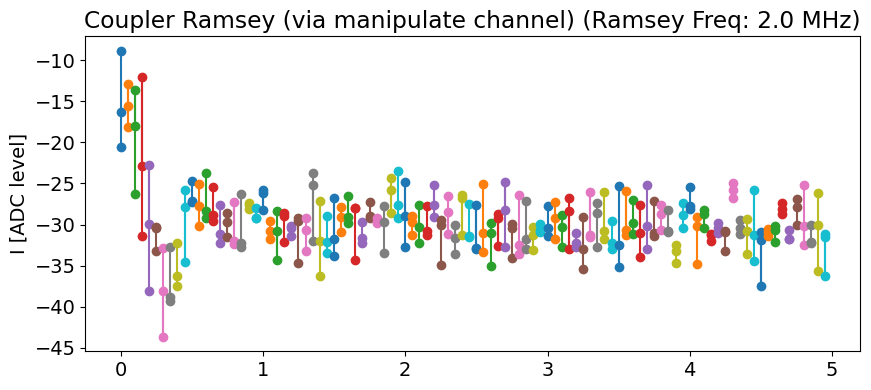

In [41]:
# Coupler sweep: include N=0 Ramsey + CPMG N>=1 with per-point ramsey_freq.
# For N=0 use the measured residual detuning so the fringes are well-resolved;
# for N>=1 use a small virtual detuning so the CPMG envelope dominates.
# N_values_cpl = [0, 1, 2, 4, 8]
N_values_cpl = [1, 2, 4, 8]

def coupler_ramsey_freq_for(N, _cfg):
    if int(N) == 0:
        f0 = coupler_ramsey_offset_at_I if coupler_ramsey_offset_at_I is not None else 1.0
        print(f'  [N=0] Using ramsey_freq={f0:.4f} MHz from lookup (residual detuning)')
        return {'ramsey_freq': float(f0)}
    return {'ramsey_freq': 2.0}

mother_cpl = coupler_runner.execute(
    sweep_start=min(N_values_cpl), sweep_stop=max(N_values_cpl),
    sweep_npts=len(N_values_cpl),
    sweep_vals=N_values_cpl,
    per_point_cfg=coupler_ramsey_freq_for,
)

Coupler T2(N) [us]:
  N=  1  T2=   0.495 us  envelope=gauss
  N=  2  T2=   0.495 us  envelope=gauss
  N=  4  T2=   0.495 us  envelope=exp
  N=  8  T2=   1.309 us  envelope=exp


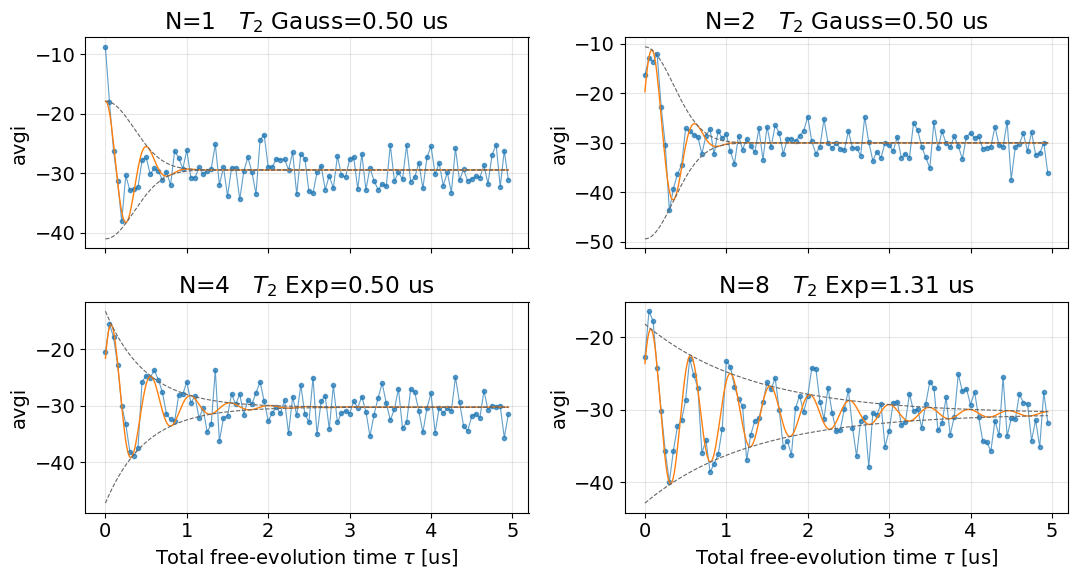

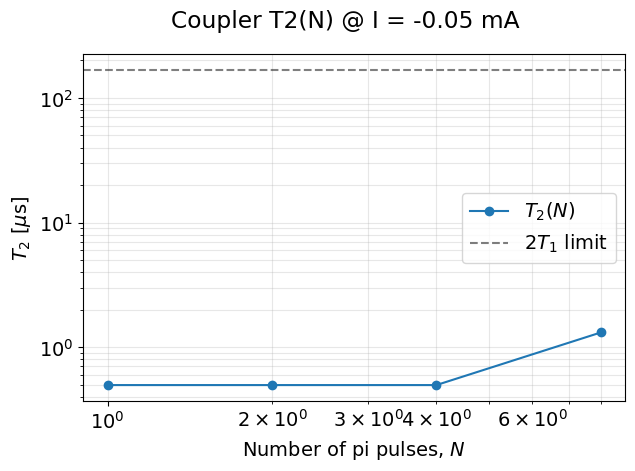

In [42]:
fits_cpl = fit_cpmg_decays(
    mother_cpl.data,
    channel='avgi',
    sweep_param_key='echoes_sweep',
)
print('Coupler T2(N) [us]:')
for N, T2, env in zip(fits_cpl['N_values'], fits_cpl['T2'], fits_cpl['envelope']):
    print(f'  N={int(N):3d}  T2={T2:8.3f} us  envelope={env}')

# Per-N Ramsey-vs-time view with fit overlay.
fig = plot_cpmg_decays(mother_cpl.data, fits_cpl, channel='avgi',
                       sweep_param_key='echoes_sweep')
plt.show()

# T1_coupler was resolved from T1_coupler_lookup(coupler_I_mA) in the working-point cell.
fig = plot_T2_vs_N(fits_cpl, T1=T1_coupler)
fig.suptitle(f'Coupler T2(N) @ I = {coupler_I_mA} mA')
plt.show()

[simple] 3 points across 3 N values
[data-driven] 269 points across 4 N values


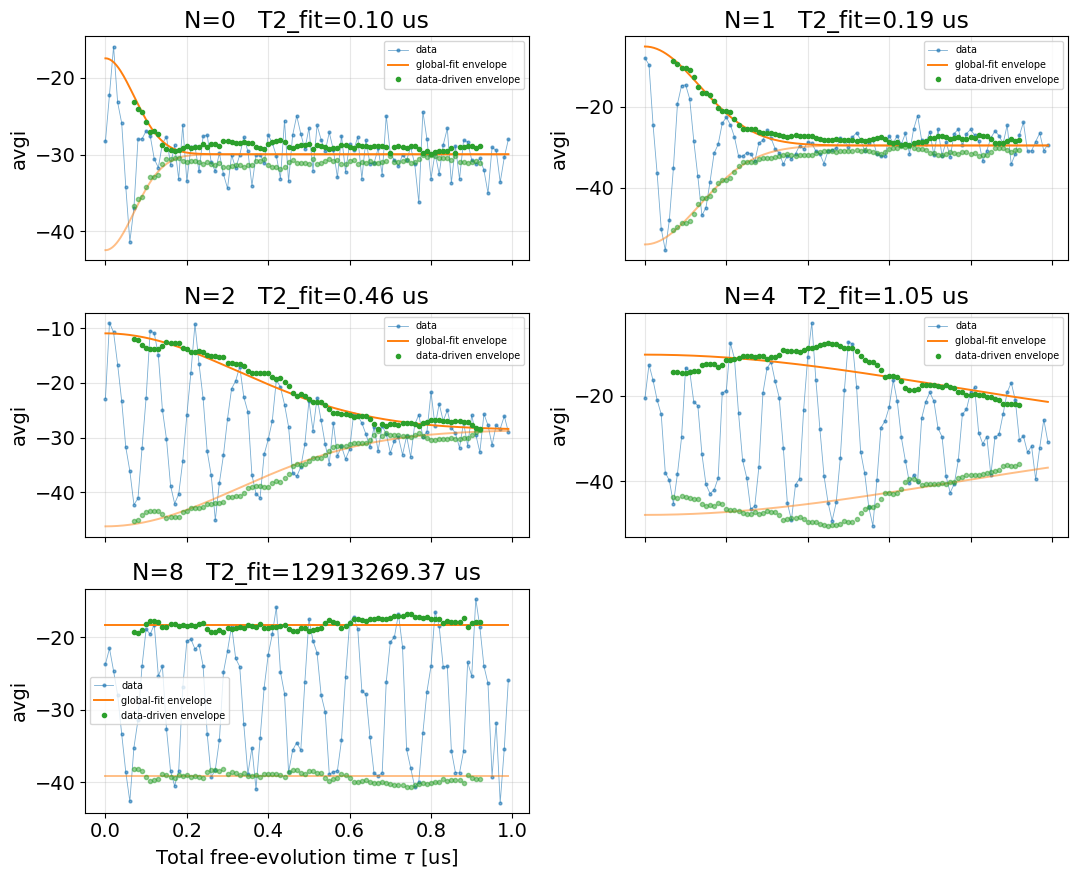

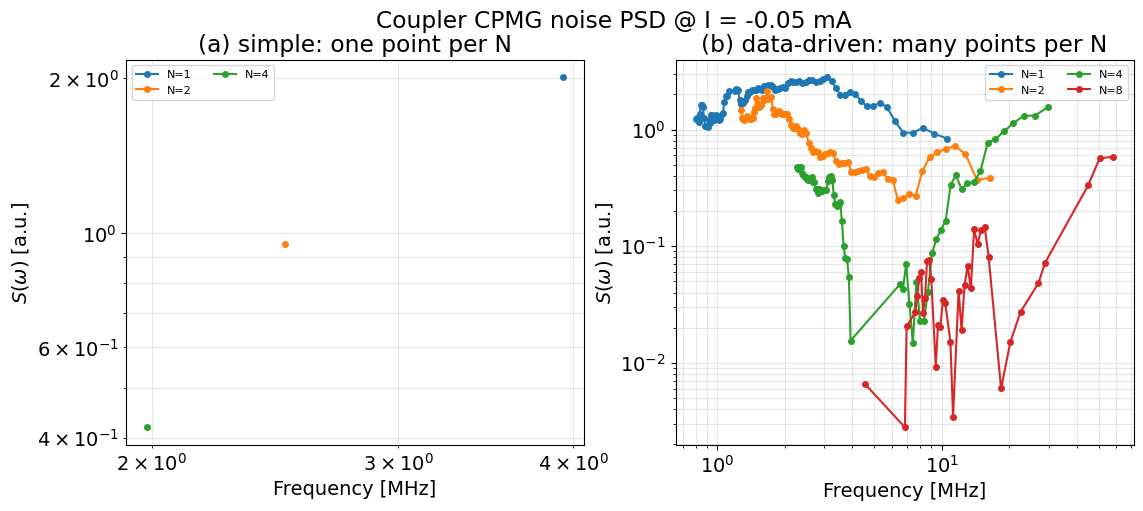

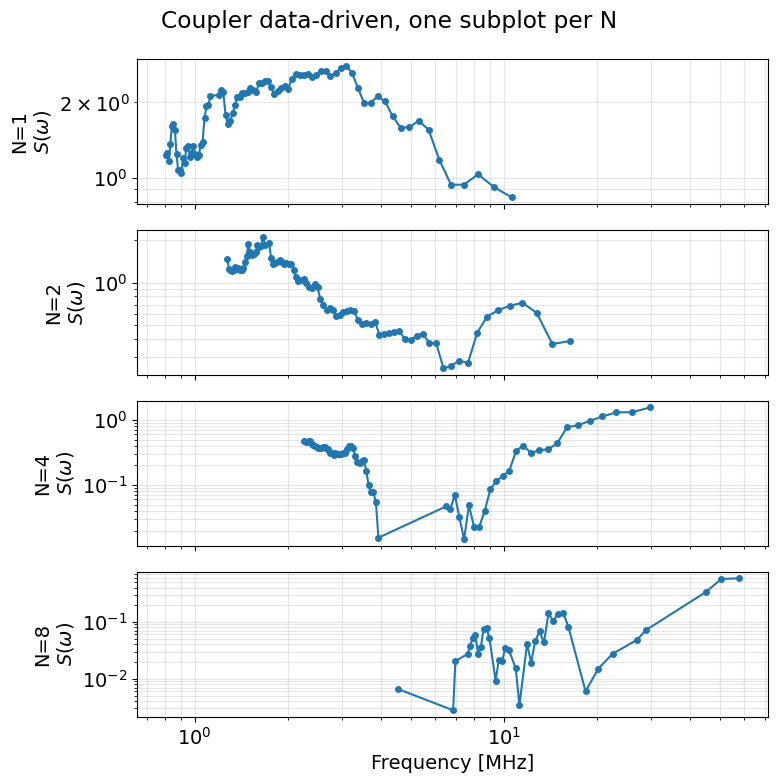

In [36]:
tau_pi_cpl = 0.0  # us — adjust to your measured coupler pi-pulse width

psd_cpl_simple = extract_psd_narrow_filter(
    fits_cpl, mode='simple', T1=T1_coupler, dwdlambda=1.0, tau_pi=tau_pi_cpl,
)
print(f'[simple] {len(psd_cpl_simple["freq_MHz"])} points across '
      f'{len(np.unique(psd_cpl_simple["N"]))} N values')

psd_cpl_data = extract_psd_narrow_filter(
    fits_cpl, mode='data_driven',
    mother_data=mother_cpl.data, channel='avgi',
    sweep_param_key='echoes_sweep',
    T1=T1_coupler, dwdlambda=1.0, tau_pi=tau_pi_cpl,
    tau_skip_initial=2, env_window=15, env_floor_frac=0.02,
    env_anchor='global_fit',
)
print(f'[data-driven] {len(psd_cpl_data["freq_MHz"])} points across '
      f'{len(np.unique(psd_cpl_data["N"]))} N values')

fig = plot_envelope_diagnostic(mother_cpl.data, fits_cpl, channel='avgi',
                               sweep_param_key='echoes_sweep', window=15)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_psd(psd_cpl_simple, ax=axes[0], style='overlay')
axes[0].set_title('(a) simple: one point per N')
plot_psd(psd_cpl_data, ax=axes[1], style='overlay')
axes[1].set_title('(b) data-driven: many points per N')
fig.suptitle(f'Coupler CPMG noise PSD @ I = {coupler_I_mA} mA')
plt.show()

fig = plot_psd(psd_cpl_data, style='faceted')
fig.suptitle('Coupler data-driven, one subplot per N')
plt.show()

## 3) Optional: scan multiple working points

Outer Python loop over coupler current. Re-resolve the lookups at each step and
update the runner's default_expt_cfg in-place, then re-execute. Works for both
M1 and the coupler.
```python
psd_by_current = {}
for I_mA in [0.25, 0.30, 0.35]:
    # Re-resolve from lookups:
    coupler_current_A  = I_mA * 1e-3
    f0g1_freq_at_I     = f0g1_lookup(I_mA)
    coupler_drive_at_I = coupler_drive_lookup(I_mA)
    T1_M1              = T1_M1_lookup(I_mA)

    # M1 path:
    manipulate_cfg.coupler_current = coupler_current_A
    manipulate_cfg.f0g1_freq       = f0g1_freq_at_I
    mother = manipulate_runner.execute(
        min(N_values_man), max(N_values_man),
        len(N_values_man), sweep_vals=N_values_man)
    fits = fit_cpmg_decays(mother.data, sweep_param_key='echoes_sweep')
    psd_by_current[I_mA] = extract_psd_narrow_filter(fits, T1=T1_M1)
```